In [17]:
'''
month
butter_cpi (Verbraucherpreisindex Butter)
dairy_ppi (Produktionspreisindex raw milk)
dairy_cpi (Verbraucherpreisindex raw milk)
'''
# Frage : 
# What patterns of asymmetric price transmission can be 
# observed between raw milk producer prices and retail butter prices in Germany?
# in eigenen Worten :
# Wie können asymmetrische Preisübertragungen zwischen Erzeugerpreisen 
# und Verbraucherpreisen in Deutschland beobachtet werden?


'\nmonth\nbutter_cpi (Verbraucherpreisindex Butter)\ndairy_ppi (Produktionspreisindex raw milk)\ndairy_cpi (Verbraucherpreisindex raw milk)\n'

In [18]:
import json
import pandas as pd
import plotly.express as px


def eurostat_json_to_df(data): # convert json to tabular
    """
    Convert a Eurostat JSON dataset into a clean monthly DataFrame.

    Parameters
    ----------
    data : dict
        Eurostat JSON data.

    Returns
    -------
    pandas.DataFrame
        DataFrame with columns month and value.
    """

    time_index = data["dimension"]["time"]["category"]["index"] # Zeitindex extrahieren
    time_df = pd.DataFrame(list(time_index.items()), columns=["month", "pos"]) # Dataframe erstellen

    values = data["value"] # Zeitindex extrahieren
    value_df = pd.DataFrame(list(values.items()), columns=["pos", "value"])
    value_df["pos"] = value_df["pos"].astype(int) # Datentyp zum String korrigieren 

    # Tabellen zusammenführen 
    df = pd.merge(time_df, value_df, on="pos")
    df = df.drop(columns=["pos"]) # pos löschen 

    return df

# laden der Daten
with open("eurostat_butter_cpi.json", "r", encoding="utf-8") as file:
    data_butter = json.load(file)

with open("eurostat_ppi_dairy.json", "r", encoding="utf-8") as file:
    data_ppi = json.load(file)

with open("eurostat_cpi_dairy.json", "r", encoding="utf-8") as file:
    data_cpi = json.load(file)

# funktion ausführen
butter_df = eurostat_json_to_df(data_butter) 
ppi_df = eurostat_json_to_df(data_ppi)
cpi_df = eurostat_json_to_df(data_cpi)


print("Butter CPI")
print(butter_df.head())

print("\nDairy PPI")
print(ppi_df.head())

print("\nDairy CPI")
print(cpi_df.head())

Butter CPI
     month  value
0  2014-12   99.3
1  2015-01   99.3
2  2015-02   99.0
3  2015-03  105.7
4  2015-04  106.2

Dairy PPI
     month  value
0  2000-01   85.1
1  2000-02   85.0
2  2000-03   85.2
3  2000-04   85.1
4  2000-05   84.9

Dairy CPI
     month  value
0  1996-01   79.9
1  1996-02   79.9
2  1996-03   80.0
3  1996-04   80.1
4  1996-05   79.9


In [19]:
# Cleaning Teil 1 : 

# Convert month column to datetime
# Zeilentyp zu Datumswerte konvertieren
butter_df["month"] = pd.to_datetime(butter_df["month"])
ppi_df["month"] = pd.to_datetime(ppi_df["month"])
cpi_df["month"] = pd.to_datetime(cpi_df["month"])

# Rename value columns
# Spalten umbenennen
butter_df = butter_df.rename(columns={"value": "butter_cpi"})
ppi_df = ppi_df.rename(columns={"value": "dairy_ppi"})
cpi_df = cpi_df.rename(columns={"value": "dairy_cpi"})

# Sort by month
butter_df = butter_df.sort_values("month").reset_index(drop=True)
ppi_df = ppi_df.sort_values("month").reset_index(drop=True)
cpi_df = cpi_df.sort_values("month").reset_index(drop=True)

#  cleaned tables
print("Cleaned Butter CPI")
print(butter_df.head())

print("\nCleaned Dairy PPI")
print(ppi_df.head())

print("\nCleaned Dairy CPI")
print(cpi_df.head())

Cleaned Butter CPI
       month  butter_cpi
0 2014-12-01        99.3
1 2015-01-01        99.3
2 2015-02-01        99.0
3 2015-03-01       105.7
4 2015-04-01       106.2

Cleaned Dairy PPI
       month  dairy_ppi
0 2000-01-01       85.1
1 2000-02-01       85.0
2 2000-03-01       85.2
3 2000-04-01       85.1
4 2000-05-01       84.9

Cleaned Dairy CPI
       month  dairy_cpi
0 1996-01-01       79.9
1 1996-02-01       79.9
2 1996-03-01       80.0
3 1996-04-01       80.1
4 1996-05-01       79.9


In [20]:
# Cleaning Teil 2 : Datenbereinigung

# Anzahl der Zeilen vorher
butter_before = len(butter_df)
ppi_before = len(ppi_df)
cpi_before = len(cpi_df)

# Zeitraum filtern 2020-2023 Inflationsperiode 
butter_df = butter_df[(butter_df["month"] >= "2020-01-01") & (butter_df["month"] <= "2023-12-01")]
ppi_df = ppi_df[(ppi_df["month"] >= "2020-01-01") & (ppi_df["month"] <= "2023-12-01")]
cpi_df = cpi_df[(cpi_df["month"] >= "2020-01-01") & (cpi_df["month"] <= "2023-12-01")]

# Anzahl nach Zeitraum filtern: 
butter_afterTime = len(butter_df)
ppi_afterTime = len(ppi_df)
cpi_afterTime = len(cpi_df)

# Fehlende Werte entfernen
butter_df = butter_df.dropna()
ppi_df = ppi_df.dropna()
cpi_df = cpi_df.dropna()

# Duplikate entfernen
butter_df = butter_df.drop_duplicates()
ppi_df = ppi_df.drop_duplicates()
cpi_df = cpi_df.drop_duplicates()

# Sortieren und Index zurücksetzen
butter_df = butter_df.sort_values("month").reset_index(drop=True)
ppi_df = ppi_df.sort_values("month").reset_index(drop=True)
cpi_df = cpi_df.sort_values("month").reset_index(drop=True)

# Anzahl der Zeilen nach Cleaning
butter_after = len(butter_df)
ppi_after = len(ppi_df)
cpi_after = len(cpi_df)

# Ausgabe
print(butter_before, butter_afterTime , butter_after)
print(ppi_before,  ppi_afterTime , ppi_after)
print(cpi_before, cpi_afterTime , cpi_after)

133 48 48
288 48 48
360 48 48


In [21]:
# mergen der drei Datensätze 
# Zusammenführen 
merged_df = butter_df.merge(ppi_df, on="month")
merged_df = merged_df.merge(cpi_df, on="month")

print(merged_df.head())


       month  butter_cpi  dairy_ppi  dairy_cpi
0 2020-01-01       144.9      111.4      110.9
1 2020-02-01       143.3      111.9      110.9
2 2020-03-01       142.7      111.4      111.1
3 2020-04-01       142.5      109.6      111.6
4 2020-05-01       142.3      108.1      113.2


In [22]:
# Veränderung zum vorherigen Monat
# Preisveränderung
merged_df["ppi_change"] = merged_df["dairy_ppi"].diff()
merged_df["butter_change"] = merged_df["butter_cpi"].diff()


print(merged_df.head())

       month  butter_cpi  dairy_ppi  dairy_cpi  ppi_change  butter_change
0 2020-01-01       144.9      111.4      110.9         NaN            NaN
1 2020-02-01       143.3      111.9      110.9         0.5           -1.6
2 2020-03-01       142.7      111.4      111.1        -0.5           -0.6
3 2020-04-01       142.5      109.6      111.6        -1.8           -0.2
4 2020-05-01       142.3      108.1      113.2        -1.5           -0.2


In [23]:
# Monate trennen in denen producerpreise gestiegen sind und gefallen sind
# Positive vs. negative Producer-Preisänderungen trennen
# Separate months with increasing and decreasing producer prices
ppi_increase = merged_df[merged_df["ppi_change"] > 0]
ppi_decrease = merged_df[merged_df["ppi_change"] < 0]

print(len(ppi_increase))
print(len(ppi_decrease))

31
16


In [24]:
# Durchschnittliche Reaktion der Butterpreise berechnen
# Average butter price reaction
butter_reaction_increase = ppi_increase["butter_change"].mean() # monate in denen producerpreie gestiegen sind
butter_reaction_decrease = ppi_decrease["butter_change"].mean() # monate in denen producerpreie gefallen sind

print(butter_reaction_increase, "Producerpreise steigen") 
print(butter_reaction_decrease, "Producerpreise fallen")

# Wenn Producerpreise steigen, dann ändern sich die Butterpreise um 2.63 
# Wenn Producerpreise fallen, dann ändern sich die Butterpreise um - 3.71

# Wenn Producerpreise fallen, allen Butterpreise im Durchschnitt stärker.

2.629032258064516 Producerpreise steigen
-3.7125000000000004 Producerpreise fallen


In [25]:
# Zusätzliche Spalte hinzugefügt 
# ob decrease oder increase der ppi
merged_df["ppi_direction"] = merged_df["ppi_change"].apply(
    lambda x: "increase" if x > 0 else "decrease"
)

merged_df.head()


,month,butter_cpi,dairy_ppi,dairy_cpi,ppi_change,butter_change,ppi_direction
0,2020-01-01,144.9,111.4,110.9,NaN,NaN,decrease
1,2020-02-01,143.3,111.9,110.9,0.5,-1.6,increase
2,2020-03-01,142.7,111.4,111.1,-0.5,-0.6,decrease
3,2020-04-01,142.5,109.6,111.6,-1.8,-0.2,decrease
4,2020-05-01,142.3,108.1,113.2,-1.5,-0.2,decrease


In [26]:
# Visualisierung 
fig = px.scatter(
    merged_df,
    x="ppi_change",
    y="butter_change",
    color="ppi_direction",
    title="Price Transmission between Producer Prices and Butter Prices",
    labels={
        "ppi_change": "Change in Dairy Producer Price Index",
        "butter_change": "Change in Butter Consumer Price Index"
    }
)

fig.show()

In [27]:
'''
ScatterPlot um den Zusammenhang zzwischen zweien Preisen zu visualisieren.
Die Grafik zeigt, dass Butterpreise grundsätzlich den Veränderungen 
der Erzeugerpreise folgen. Allerdings reagieren sie unterschiedlich stark auf 
steigende und fallende Preise. Dieses unterschiedliche Reaktionsmuster weist auf
 eine asymmetrische Preisübertragung hin.
 '''
 # jeder punkt ist ein monat
 # rot preise steigen
 # blau preise fallen 
 # da punkte untersch. verteilt sind, sieht man es ex. eine assymetrische Reaktion

'\nScatterPlot um den Zusammenhang zzwischen zweien Preisen zu visualisieren.\nDie Grafik zeigt, dass Butterpreise grundsätzlich den Veränderungen \nder Erzeugerpreise folgen. Allerdings reagieren sie unterschiedlich stark auf \nsteigende und fallende Preise. Dieses unterschiedliche Reaktionsmuster weist auf\n eine asymmetrische Preisübertragung hin.\n '

In [28]:
reaction_df = pd.DataFrame({
    "producer_price_change": ["increase", "decrease"],
    "butter_price_reaction": [
        butter_reaction_increase,
        butter_reaction_decrease
    ]
})

fig = px.bar(
    reaction_df,
    x="producer_price_change",
    y="butter_price_reaction",
    title="Average Butter Price Reaction to Producer Price Changes",
    labels={
        "producer_price_change": "Producer Price Movement",
        "butter_price_reaction": "Average Change in Butter Price"
    }
)

fig.show()

In [29]:
'''
Diese Grafik zeigt die durchschnittliche Veränderung der Butterpreise in Monaten, 
in denen die Erzeugerpreise für Milchprodukte entweder gestiegen oder gefallen sind.

Der linke Balken zeigt Monate mit steigenden Erzeugerpreisen. 
In diesen Monaten steigen auch die Butterpreise im Durchschnitt leicht. 

Der rechte Balken zeigt Monate mit fallenden Erzeugerpreisen.
 Hier sinken die Butterpreise im Durchschnitt deutlich stärker.

Der Vergleich der beiden Balken zeigt, 
dass die Reaktion der Butterpreise unterschiedlich stark ist,
 je nachdem ob die Erzeugerpreise steigen oder fallen. 
 Dies deutet auf eine asymmetrische Preisübertragung im Buttermarkt hin.
'''

# Butterpreise reagieren stärker auf sinkende Producerpreise 

'\nDiese Grafik zeigt die durchschnittliche Veränderung der Butterpreise in Monaten, \nin denen die Erzeugerpreise für Milchprodukte entweder gestiegen oder gefallen sind.\n\nDer linke Balken zeigt Monate mit steigenden Erzeugerpreisen. \nIn diesen Monaten steigen auch die Butterpreise im Durchschnitt leicht. \n\nDer rechte Balken zeigt Monate mit fallenden Erzeugerpreisen.\n Hier sinken die Butterpreise im Durchschnitt deutlich stärker.\n\nDer Vergleich der beiden Balken zeigt, \ndass die Reaktion der Butterpreise unterschiedlich stark ist,\n je nachdem ob die Erzeugerpreise steigen oder fallen. \n Dies deutet auf eine asymmetrische Preisübertragung im Buttermarkt hin.\n'

In [30]:
# Website 
merged_df.to_csv("rq1_data.csv", index=False)

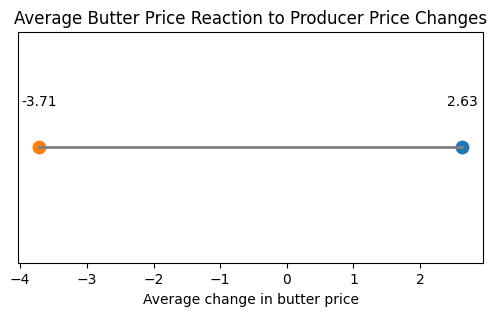

In [31]:
import matplotlib.pyplot as plt
labels = ["Producer price increase", "Producer price decrease"]
values = [butter_reaction_increase, butter_reaction_decrease]

plt.figure(figsize=(6,3))

# Linie
plt.plot(values, [1,1], color="gray", linewidth=2)

# Punkte
plt.scatter(values[0], 1, s=80)
plt.scatter(values[1], 1, s=80)

# Werte anzeigen
plt.text(values[0], 1.02, round(values[0],2), ha="center")
plt.text(values[1], 1.02, round(values[1],2), ha="center")

plt.yticks([])
plt.xlabel("Average change in butter price")
plt.title("Average Butter Price Reaction to Producer Price Changes")

plt.show()